In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [2]:
# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

In [3]:
custom_model = torch.load('best_deep_silu_bn_v3.pt', map_location=device, weights_only=False)
custom_model = custom_model.to(device)
custom_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
# unfreeze layer4
for param in custom_model.layer4.parameters():
    param.requires_grad = True

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda x: x.requires_grad, custom_model.parameters()), lr=1e-5,
                                   weight_decay=5e-3)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
deep_ft, metrics_ft = train_model(custom_model, criterion, optimizer, scheduler, dataloaders,
                                          dataset_sizes, 30)

val Loss: 0.7616 | Acc: 0.7296 | Weighted Acc: 0.6991 | F1-macro: 0.7335 | Top-1 Acc: 0.7296 | Top-3 Acc: 0.9446
Epoch Time: 19.7844s

Training complete in 9m 55s
Best val Weighted Acc: 0.706615 | Best F1-score: 0.7400 | Best Top-1 Acc: 0.7378 | Best Top-3 Acc: 0.9463


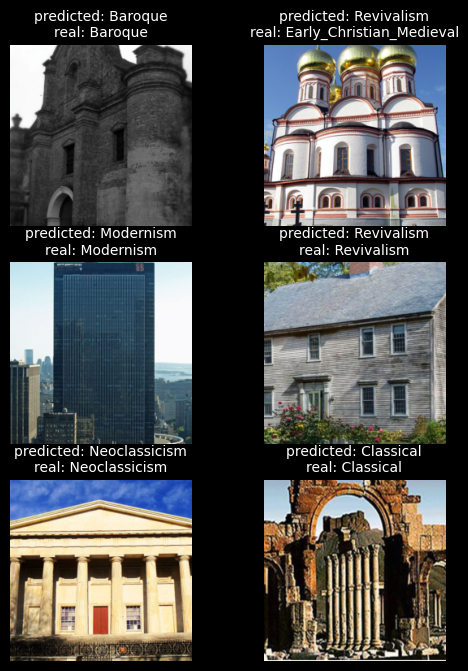

In [6]:
visualize_model(deep_ft, num_images=6, class_names=class_names, vis_loader=vis_loader)

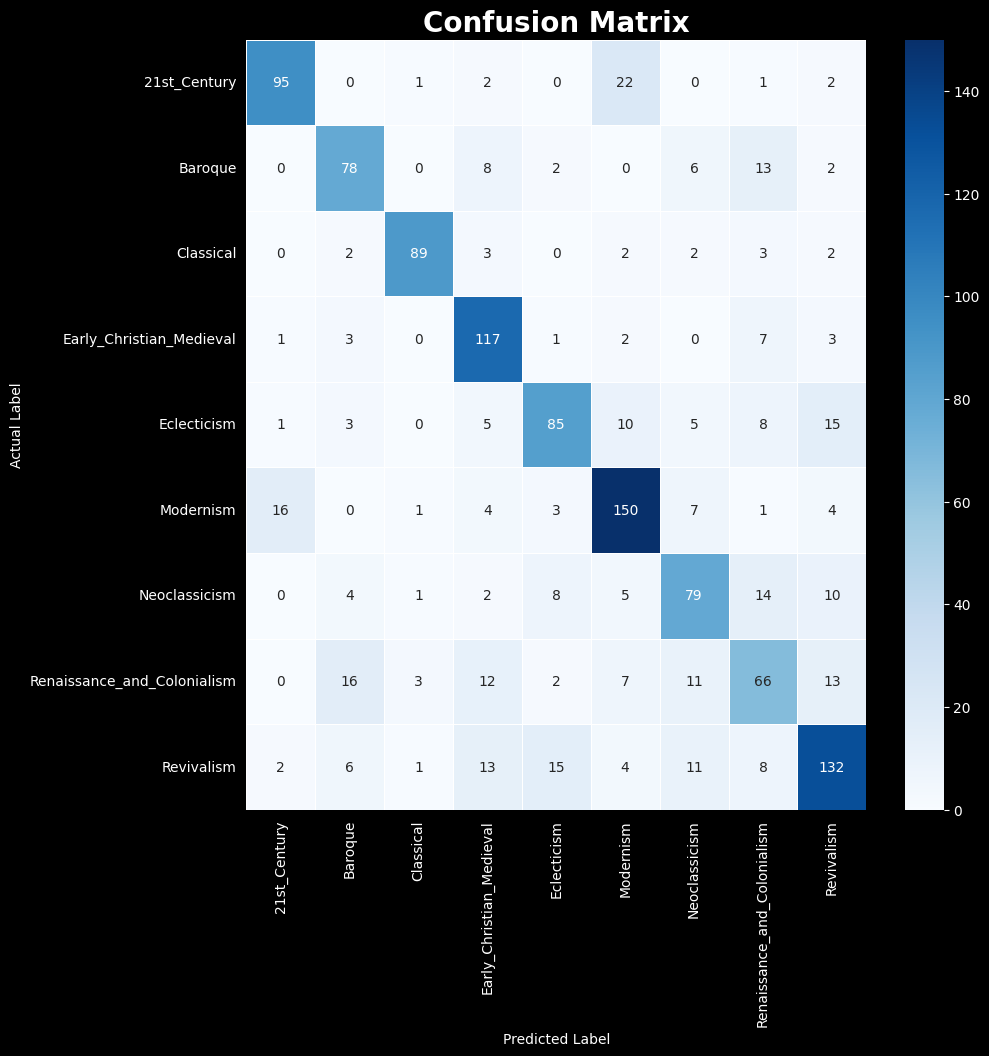

In [7]:
visualize_cm(deep_ft, class_names, test_set)

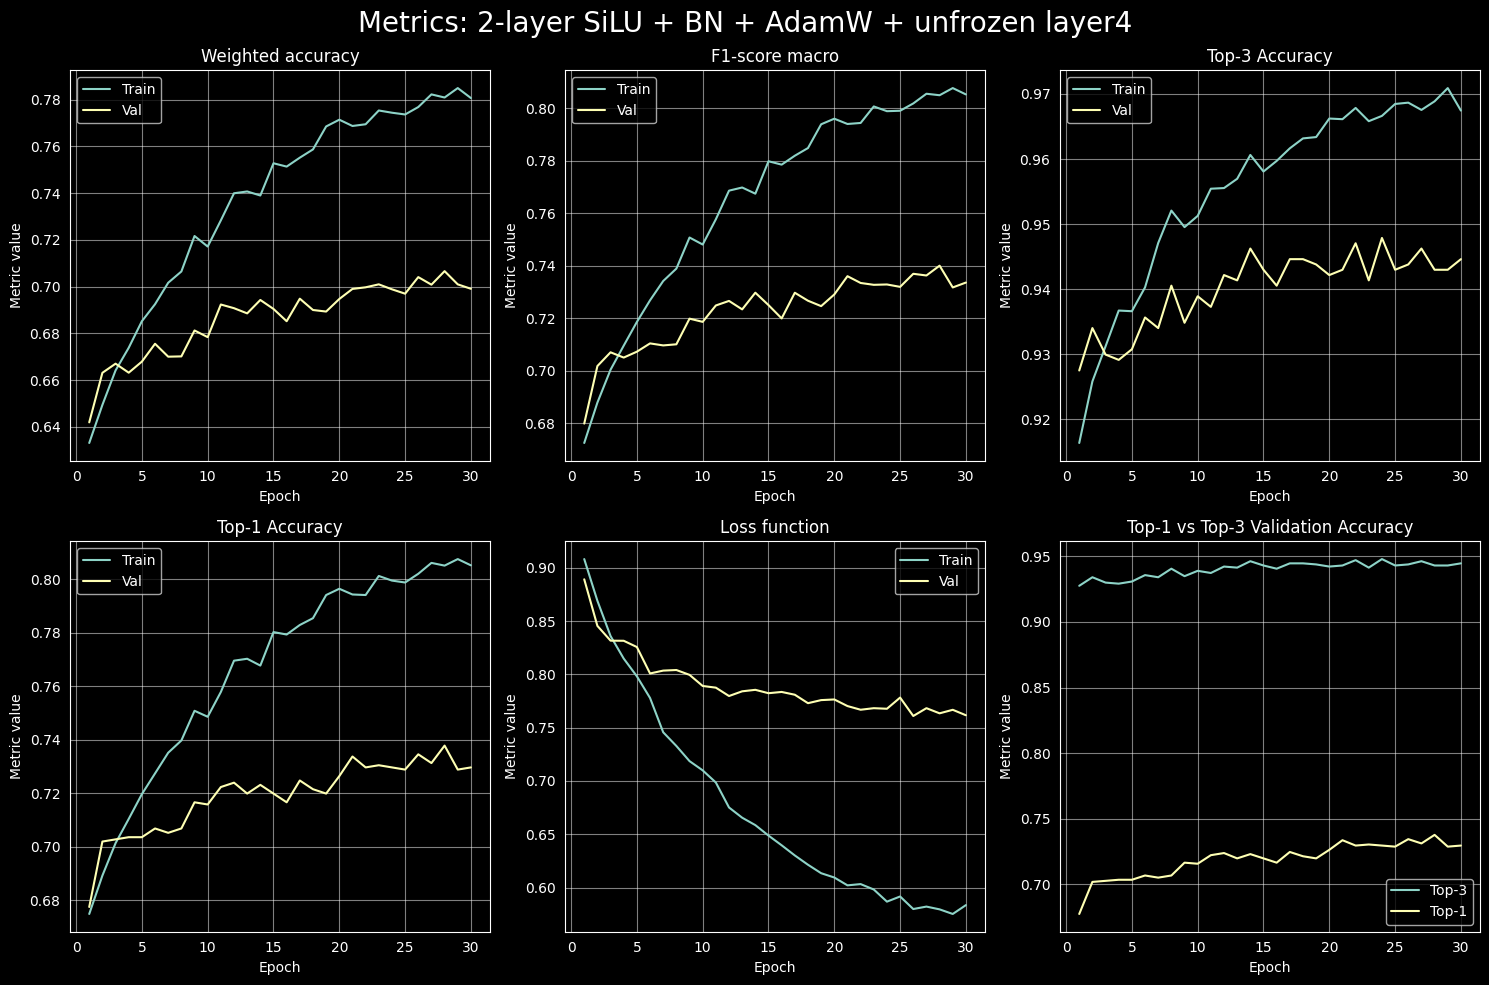

In [10]:
visualize_metrics(metrics_ft, "Metrics: 2-layer SiLU + BN + AdamW + unfrozen layer4", len(metrics_ft[0]))

In [11]:
torch.save(deep_ft, 'best_deep_silu_bn_f1_074.pt')